# 11 Gene-Level Feature Importance from PC Models

**Goal:** Trace PC-based model predictions back to individual genes.  
For qualifying tissue × pathology pairs (PC+Conf AUC ≥ 0.60, Δ ≥ 0.05).

**Two-step normalization** ensures gene importances are proper proportions (sum to 1):
1. **Step 1:** Renormalize RF Gini importances (PCs only) → `Σ RF_imp_norm = 1`
2. **Step 2:** Normalize |loadings| per PC → `Σ |loading_norm(i,j)| = 1` for each PC

**Formula:** `gene_j = Σ_i RF_imp_norm_i × |loading_norm(i,j)|`

→ `Σ_j gene_j = 1` — each gene's importance is a proportion of total predictive signal.

**Approach:** Run Liver | cirrhosis first as proof of concept, then scale to all qualifying pairs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import load_cache, build_confounder_matrix, variance_filter
from gtex_biomarkers.labels import assign_donor_labels
from gtex_biomarkers.models import make_rf_model, _auc_feature_selection

Config.ensure_dirs()

# ── Load data ──
X_wb, blood_subjid, _, df_meta_url, df_age = load_cache()
X_conf = build_confounder_matrix(df_age, blood_subjid)

# ── Variance filter — same 20K genes as NB07 and NB10 ──
X_wb_var, gene_var = variance_filter(X_wb)
print(f'Variance filter: {X_wb.shape[1]:,} → {X_wb_var.shape[1]:,} genes')

# ── Ensembl ID → gene symbol ──
gene_map_df = pd.read_csv(Config.EXPR_FILE, sep="\t", skiprows=2,
                           usecols=["Name", "Description"], nrows=60000)
gene_id_to_name = dict(zip(gene_map_df["Name"].astype(str),
                            gene_map_df["Description"].astype(str)))

# ── NB07 direct RF importance (for validation) ──
rf_fi = pd.read_csv(Config.TABLES_DIR / "rf_feature_importances.csv")

print(f"Expression: {X_wb_var.shape[0]} samples x {X_wb_var.shape[1]:,} genes")
print(f"Gene mapping: {len(gene_id_to_name):,}")
print(f"NB07 RF importance: {len(rf_fi)} rows")

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes
Variance filter: 59,033 → 20,000 genes
Expression: 803 samples x 20,000 genes
Gene mapping: 59,033
NB07 RF importance: 16163 rows


## 11.1 — Filter Qualifying Models

From NB10: PC+Conf AUC ≥ 0.60 and Δ ≥ 0.05.

In [2]:
AUC_THRESH = 0.60
DELTA_THRESH = 0.05
N_PCS = 800
TOP_K_PCS = 100
TOP_N_GENES = 30

pc_results = pd.read_csv(Config.TABLES_DIR / "pc_auc_results.csv")

qualified_all = pc_results[
    (pc_results["auc_pc_conf"] >= AUC_THRESH) & (pc_results["delta_pc"] >= DELTA_THRESH)
].reset_index(drop=True)

print(f"Total pairs: {len(pc_results)}")
print(f"Qualifying (AUC >= {AUC_THRESH}, Δ >= {DELTA_THRESH}): {len(qualified_all)}")
print()
display(qualified_all[["tissue", "category", "auc_pc_conf", "delta_pc"]].sort_values("delta_pc", ascending=False))

Total pairs: 53
Qualifying (AUC >= 0.6, Δ >= 0.05): 9



,tissue,category,auc_pc_conf,delta_pc
0,Liver,cirrhosis,0.785191,0.218326
1,Liver,steatosis,0.644392,0.136233
2,Spleen,congestion,0.803827,0.083153
3,Muscle - Skeletal,atrophy,0.697917,0.079167
4,Artery - Tibial,monckeberg,0.643333,0.067705
5,Artery - Tibial,atherosis,0.601319,0.067211
6,Lung,congestion,0.646925,0.059096
7,Breast - Mammary Tissue,atrophy,0.827713,0.055429
8,Lung,edema,0.619494,0.051394


## 11.2 — Shared Functions

In [3]:
def run_cv_with_artifacts(X, y, groups, X_conf_sub,
                          n_pcs=N_PCS, top_k_pcs=TOP_K_PCS, tag=""):
    """Leak-free CV that returns PCA loadings + normalized RF importances per fold."""
    cv = StratifiedGroupKFold(n_splits=Config.N_SPLITS, shuffle=True,
                              random_state=Config.SEED)
    fold_artifacts = []

    for fold, (tr, te) in enumerate(cv.split(X, y, groups=groups), 1):
        Xtr = X.iloc[tr]
        ytr = y.iloc[tr]

        scaler = StandardScaler()
        Xtr_scaled = scaler.fit_transform(Xtr)
        n_comp = min(n_pcs, Xtr_scaled.shape[0] - 1, Xtr_scaled.shape[1])
        pca = PCA(n_components=n_comp, random_state=Config.SEED)
        Xtr_pcs = pca.fit_transform(Xtr_scaled)

        pc_cols = [f"PC{i+1}" for i in range(n_comp)]
        Xtr_pcs = pd.DataFrame(Xtr_pcs, columns=pc_cols, index=Xtr.index)

        top_pcs = _auc_feature_selection(Xtr_pcs, ytr, top_k=min(top_k_pcs, n_comp))
        selected_idx = [int(c.replace("PC", "")) - 1 for c in top_pcs]

        Xtr_sel = pd.concat([Xtr_pcs[top_pcs], X_conf_sub.iloc[tr]], axis=1)

        model = make_rf_model()
        model.fit(Xtr_sel, ytr)

        # Step 1: Slice PC importances and renormalize to sum to 1
        n_pc_features = len(top_pcs)
        rf_imp_pcs = model.feature_importances_[:n_pc_features].copy()
        rf_imp_pcs = rf_imp_pcs / rf_imp_pcs.sum()

        fold_artifacts.append({
            "loadings": pca.components_,
            "selected_idx": selected_idx,
            "rf_imp_pcs": rf_imp_pcs,
        })

    print(f"  {tag}: collected artifacts from {len(fold_artifacts)} folds")
    return fold_artifacts


def compute_gene_importance(artifacts, gene_columns):
    """Compute normalized gene importance from fold artifacts."""
    n_genes = len(gene_columns)
    imp = np.zeros(n_genes)

    for art in artifacts:
        sel_loadings = art["loadings"][art["selected_idx"], :]
        rf_imp = art["rf_imp_pcs"]

        # Step 2: normalize |loadings| per PC so each row sums to 1
        abs_loadings = np.abs(sel_loadings)
        row_sums = abs_loadings.sum(axis=1, keepdims=True)
        abs_loadings_norm = abs_loadings / row_sums

        imp += (rf_imp[:, None] * abs_loadings_norm).sum(axis=0)

    imp /= len(artifacts)
    return pd.Series(imp, index=gene_columns)


def run_single_pair(tissue, category):
    """Run artifact collection + gene importance for one tissue|category pair."""
    y, _, n_pos, n_neg = assign_donor_labels(
        df_meta_url, tissue, category, blood_subjid
    )
    keep = y.notna()
    y_clean = y[keep].astype(int)
    groups = blood_subjid[keep].astype(str)
    X_sub = X_wb_var.loc[keep]
    X_conf_sub = X_conf.loc[keep]

    tag = f"{tissue} | {category}"
    print(f"  Samples: {n_pos} pos / {n_neg} neg (total {keep.sum()})")

    artifacts = run_cv_with_artifacts(X_sub, y_clean, groups, X_conf_sub, tag=tag)
    imp = compute_gene_importance(artifacts, X_wb_var.columns)
    return artifacts, imp

---
## 11.3 — Proof of Concept: Liver | Cirrhosis

Run one pair first to verify the pipeline end-to-end.

In [4]:
print("Liver | cirrhosis")
demo_artifacts, demo_imp = run_single_pair("Liver", "cirrhosis")

top5 = [gene_id_to_name.get(g, g) for g in demo_imp.nlargest(5).index]
print(f"  sum = {demo_imp.sum():.6f} (should be 1.0)")
print(f"  Top 5: {top5}")

Liver | cirrhosis
  Samples: 49 pos / 368 neg (total 417)
  Liver | cirrhosis: collected artifacts from 5 folds
  sum = 1.000000 (should be 1.0)
  Top 5: ['FAM210CP', 'GSTA7P', 'KRT77', 'MSMB', 'ENSG00000275091']


### Sanity Check: Both Normalizations

Verify on Liver | cirrhosis, fold 1:
1. RF Gini importance (PCs only) sums to 1
2. |loadings| per PC sum to 1 after normalization
3. Gene importances sum to 1 end-to-end

In [5]:
art = demo_artifacts[0]

print("Liver | cirrhosis, Fold 1")
print()

# Step 1
rf_sum = art["rf_imp_pcs"].sum()
print(f"Step 1 — Σ RF_imp_norm (PCs only): {rf_sum:.6f}  (should be 1.0)")
print()

# Step 2
sel_loadings = art["loadings"][art["selected_idx"], :]
abs_loadings = np.abs(sel_loadings)
row_sums_before = abs_loadings.sum(axis=1)
abs_loadings_norm = abs_loadings / row_sums_before[:, None]
row_sums_after = abs_loadings_norm.sum(axis=1)

print(f"Step 2 — |loadings| per PC (first 5 of {len(art['selected_idx'])} PCs):")
print(f"  Before normalization — Σ|L|: {row_sums_before[:5].round(4).tolist()}")
print(f"  After normalization  — Σ|L|: {row_sums_after[:5].round(6).tolist()}")
print()

# End-to-end
gene_imp_fold = (art["rf_imp_pcs"][:, None] * abs_loadings_norm).sum(axis=0)
print(f"End-to-end — Σ gene_importance (single fold): {gene_imp_fold.sum():.6f}  (should be 1.0)")

Liver | cirrhosis, Fold 1

Step 1 — Σ RF_imp_norm (PCs only): 1.000000  (should be 1.0)

Step 2 — |loadings| per PC (first 5 of 100 PCs):
  Before normalization — Σ|L|: [128.0254, 107.8002, 96.2316, 102.0741, 103.8624]
  After normalization  — Σ|L|: [1.0, 1.0, 1.0, 1.0, 1.0]

End-to-end — Σ gene_importance (single fold): 1.000000  (should be 1.0)


### Top 30 Genes — Liver | Cirrhosis

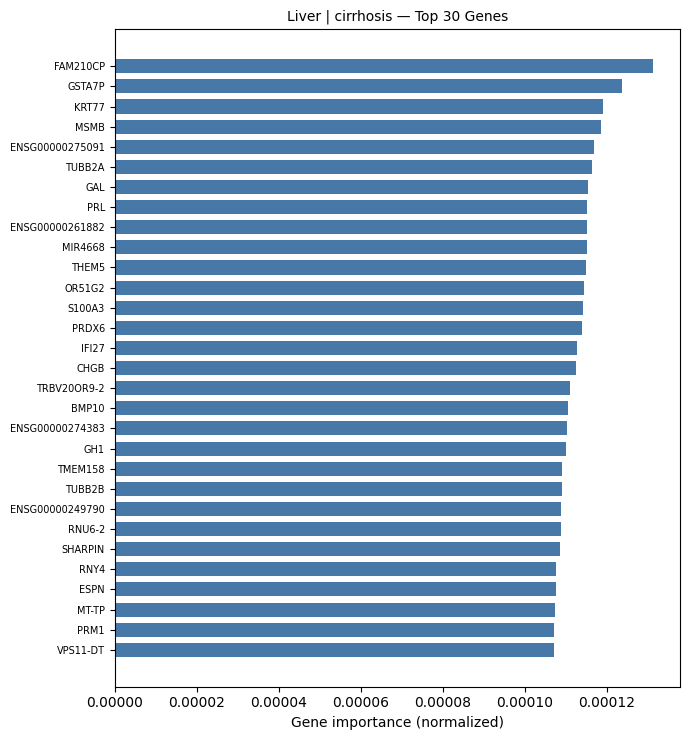

In [6]:
top = demo_imp.nlargest(TOP_N_GENES).sort_values()
labels = [gene_id_to_name.get(g, g) for g in top.index]

fig, ax = plt.subplots(figsize=(7, max(5, TOP_N_GENES * 0.25)))
ax.barh(range(len(top)), top.values, color="#4878A8", height=0.7)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Gene importance (normalized)")
ax.set_title(f"Liver | cirrhosis \u2014 Top {TOP_N_GENES} Genes", fontsize=10)
fig.tight_layout()
plt.show()

### Importance Distribution — Liver | Cirrhosis

How concentrated or diffuse is the gene importance?  
Histogram of all 20K importance scores + cumulative importance curve.

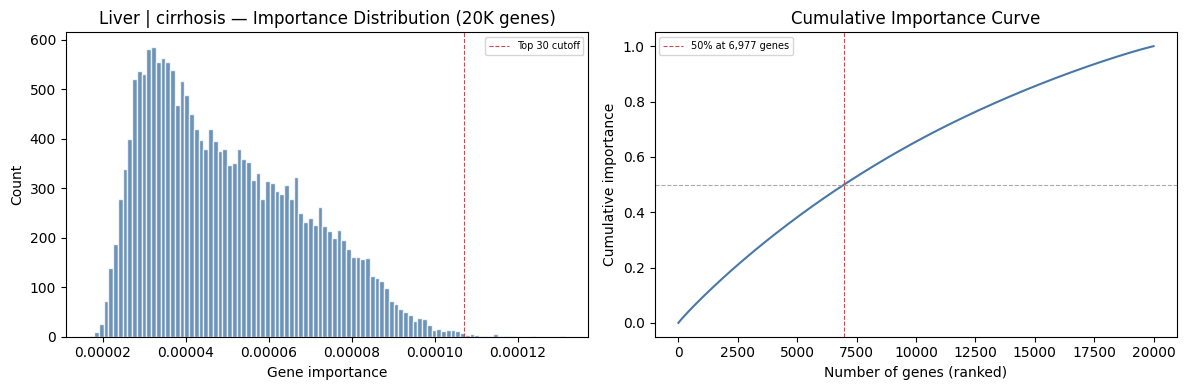

Top 30 genes hold 0.3% of total importance
Top 100 genes hold 1.1% of total importance
50% of importance reached at gene #6,977 of 20,000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of importance scores
axes[0].hist(demo_imp.values, bins=100, color="#4878A8", edgecolor="white", alpha=0.8)
axes[0].axvline(demo_imp.nlargest(30).min(), color="#C44E52", ls="--", lw=0.8, label="Top 30 cutoff")
axes[0].set_xlabel("Gene importance")
axes[0].set_ylabel("Count")
axes[0].set_title("Liver | cirrhosis — Importance Distribution (20K genes)")
axes[0].legend(fontsize=7)

# Right: cumulative importance (Lorenz-like)
sorted_imp = demo_imp.sort_values(ascending=False).values
cum_imp = np.cumsum(sorted_imp)
n_genes = len(sorted_imp)
axes[1].plot(range(1, n_genes + 1), cum_imp, color="#4878A8", lw=1.5)
axes[1].axhline(0.5, color="#AAAAAA", ls="--", lw=0.8)
# How many genes to reach 50%?
n50 = np.searchsorted(cum_imp, 0.5) + 1
axes[1].axvline(n50, color="#C44E52", ls="--", lw=0.8, label=f"50% at {n50:,} genes")
axes[1].set_xlabel("Number of genes (ranked)")
axes[1].set_ylabel("Cumulative importance")
axes[1].set_title("Cumulative Importance Curve")
axes[1].legend(fontsize=7)

fig.tight_layout()
plt.show()

print(f"Top 30 genes hold {sorted_imp[:30].sum()*100:.1f}% of total importance")
print(f"Top 100 genes hold {sorted_imp[:100].sum()*100:.1f}% of total importance")
print(f"50% of importance reached at gene #{n50:,} of {n_genes:,}")

---
## 11.4 — Scale to All Qualifying Pairs

Run the same pipeline for all 9 qualifying pairs.

In [8]:
gene_importance = {}

# Include the Liver|cirrhosis result we already computed
gene_importance[("Liver", "cirrhosis")] = demo_imp
print(f"[1/{len(qualified_all)}] Liver | cirrhosis (already done)")

# Run remaining pairs
remaining = qualified_all[
    ~((qualified_all["tissue"] == "Liver") & (qualified_all["category"] == "cirrhosis"))
]

for i, row in remaining.iterrows():
    tissue, category = row["tissue"], row["category"]
    idx = list(qualified_all.index).index(i) + 1
    print(f"\n[{idx + 1}/{len(qualified_all)}] {tissue} | {category}")

    _, imp = run_single_pair(tissue, category)
    gene_importance[(tissue, category)] = imp

    top5 = [gene_id_to_name.get(g, g) for g in imp.nlargest(5).index]
    print(f"  sum = {imp.sum():.4f}, top 5: {top5}")

print(f"\nDone — {len(gene_importance)} pairs.")

[1/9] Liver | cirrhosis (already done)

[3/9] Liver | steatosis
  Samples: 211 pos / 206 neg (total 417)
  Liver | steatosis: collected artifacts from 5 folds
  sum = 1.0000, top 5: ['FAM210CP', 'GSTA7P', 'ENSG00000281383', 'KRT77', 'TUBB2A']

[4/9] Spleen | congestion
  Samples: 469 pos / 70 neg (total 539)
  Spleen | congestion: collected artifacts from 5 folds
  sum = 1.0000, top 5: ['MT-TA', 'ENSG00000289474', 'GSTA7P', 'KRT77', 'KLK2']

[5/9] Muscle - Skeletal | atrophy
  Samples: 80 pos / 15 neg (total 95)
  Muscle - Skeletal | atrophy: collected artifacts from 5 folds
  sum = 1.0000, top 5: ['KRT77', 'MT-TA', 'MT-TC', 'GPX1P1', 'RNU6ATAC']

[6/9] Artery - Tibial | monckeberg
  Samples: 60 pos / 353 neg (total 413)
  Artery - Tibial | monckeberg: collected artifacts from 5 folds
  sum = 1.0000, top 5: ['THEM5', 'REG3A', 'IGKV6D-41', 'REG3G', 'ENSG00000281383']

[7/9] Artery - Tibial | atherosis
  Samples: 66 pos / 347 neg (total 413)
  Artery - Tibial | atherosis: collected artif

## 11.5 — Importance Distribution — All Pairs

How concentrated is the importance signal across pairs?  
Steep curve = clear biomarkers. Flat = diffuse/polygenic signal.

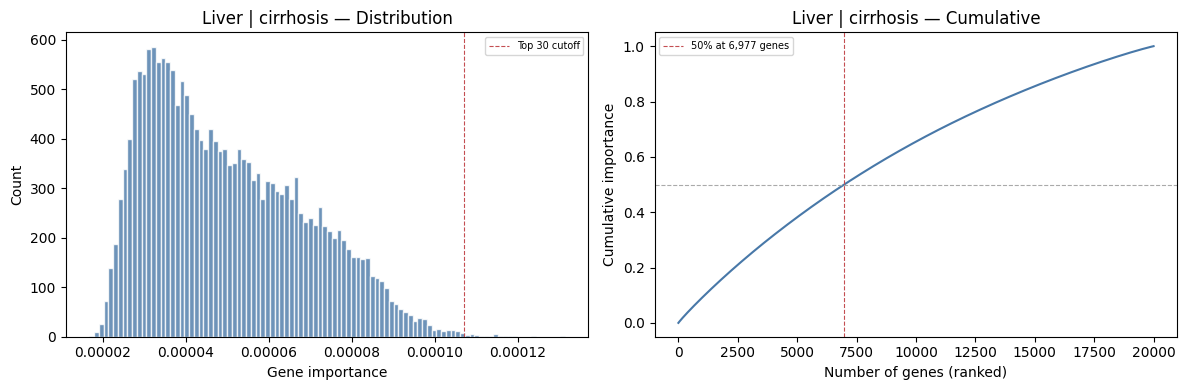

  Liver | cirrhosis: top 30 = 0.3%, top 100 = 1.1%, 50% at gene #6,977


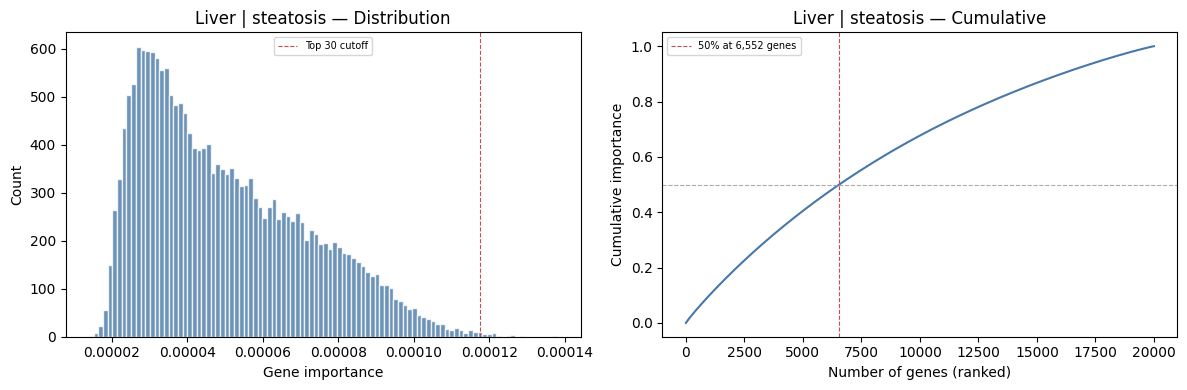

  Liver | steatosis: top 30 = 0.4%, top 100 = 1.2%, 50% at gene #6,552


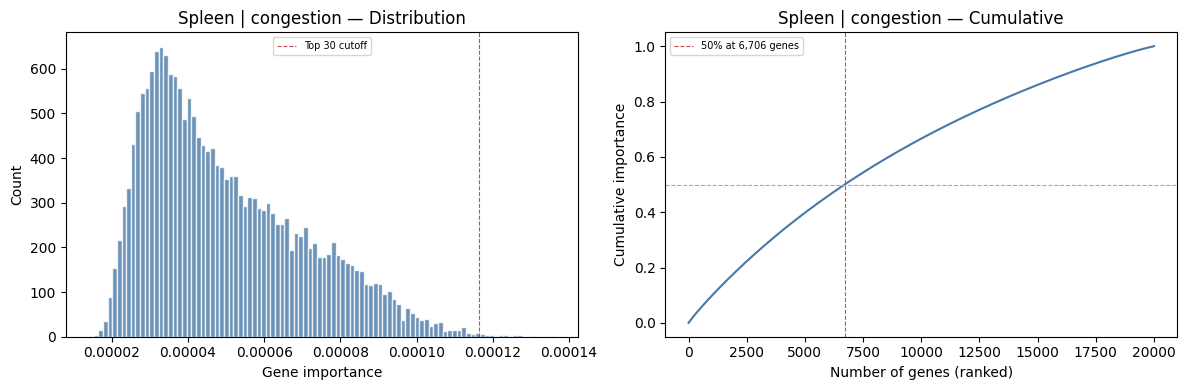

  Spleen | congestion: top 30 = 0.4%, top 100 = 1.2%, 50% at gene #6,706


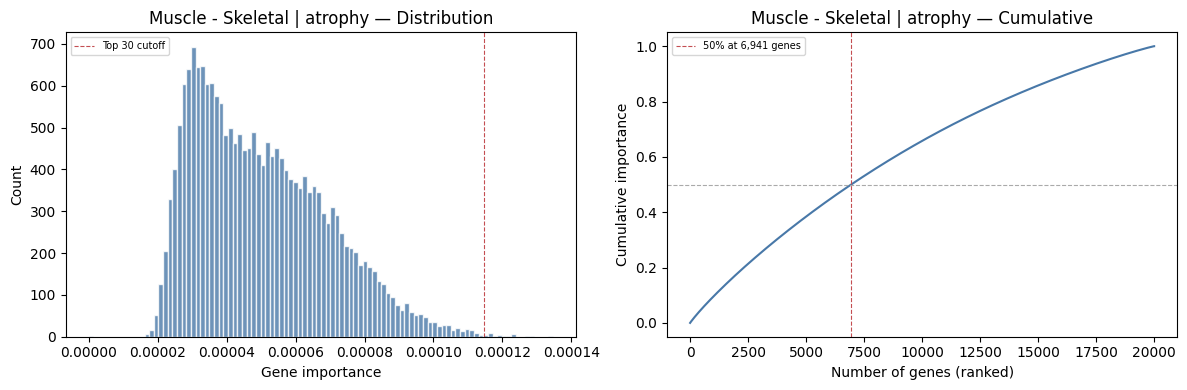

  Muscle - Skeletal | atrophy: top 30 = 0.4%, top 100 = 1.1%, 50% at gene #6,941


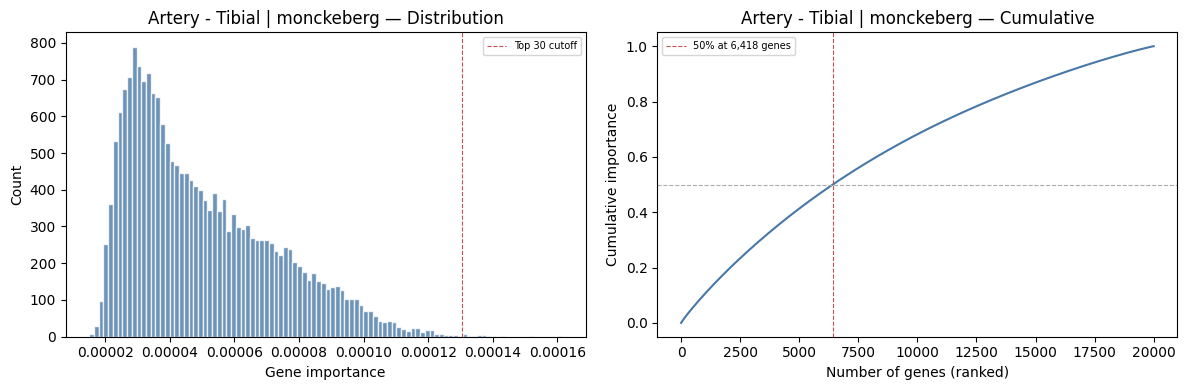

  Artery - Tibial | monckeberg: top 30 = 0.4%, top 100 = 1.3%, 50% at gene #6,418


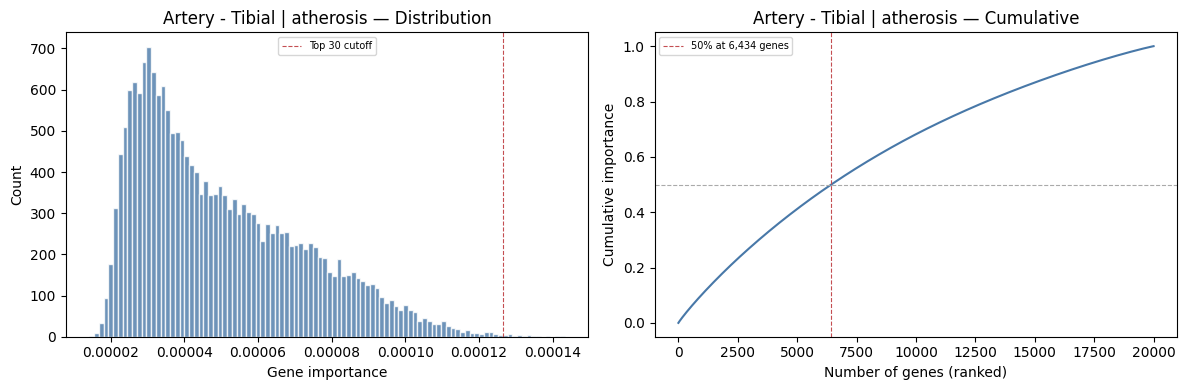

  Artery - Tibial | atherosis: top 30 = 0.4%, top 100 = 1.2%, 50% at gene #6,434


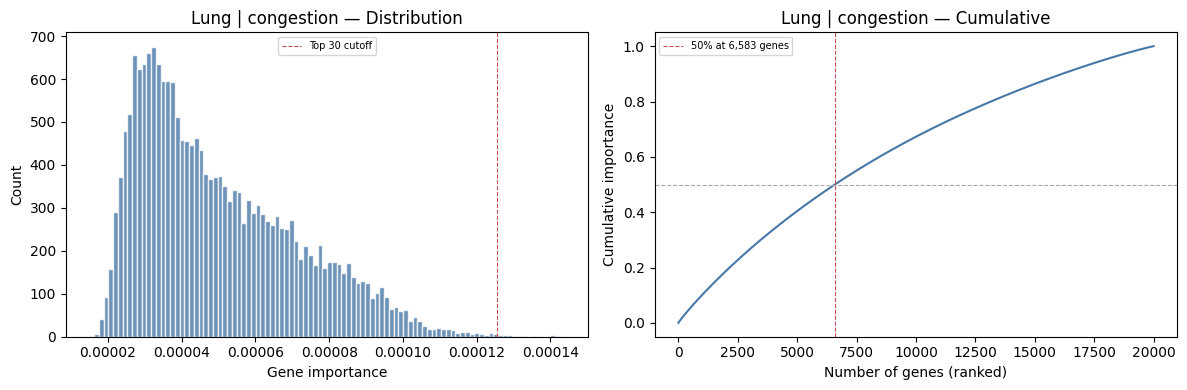

  Lung | congestion: top 30 = 0.4%, top 100 = 1.2%, 50% at gene #6,583


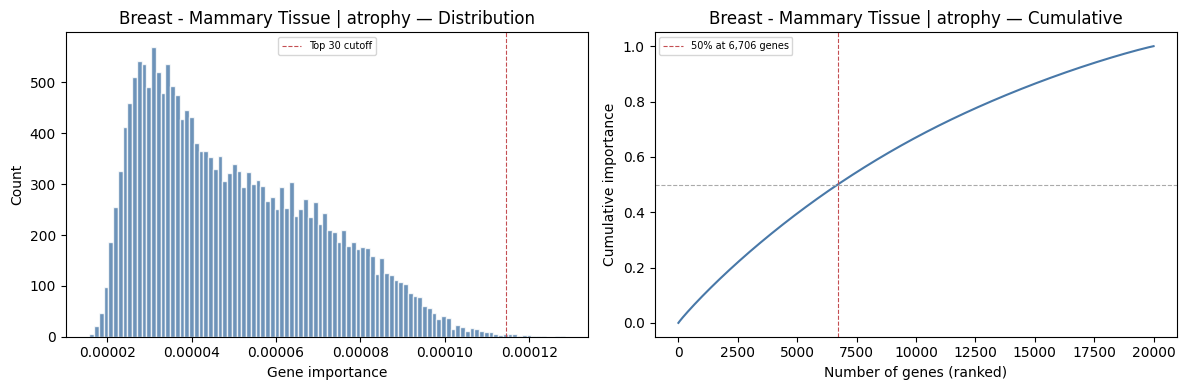

  Breast - Mammary Tissue | atrophy: top 30 = 0.4%, top 100 = 1.1%, 50% at gene #6,706


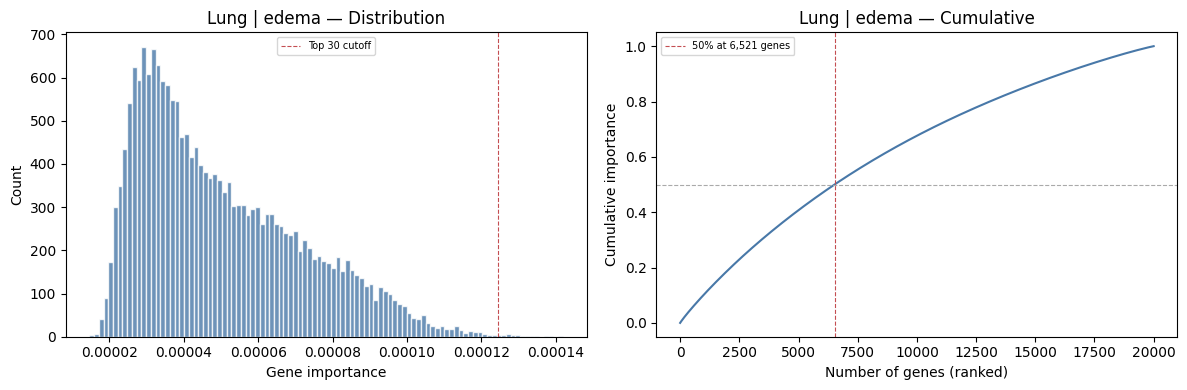

  Lung | edema: top 30 = 0.4%, top 100 = 1.2%, 50% at gene #6,521


In [9]:
for (tissue, category), imp in gene_importance.items():
    tag = f"{tissue} | {category}"
    sorted_imp = imp.sort_values(ascending=False).values
    cum_imp = np.cumsum(sorted_imp)
    n50 = np.searchsorted(cum_imp, 0.5) + 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(imp.values, bins=100, color="#4878A8", edgecolor="white", alpha=0.8)
    axes[0].axvline(imp.nlargest(TOP_N_GENES).min(), color="#C44E52", ls="--", lw=0.8,
                     label=f"Top {TOP_N_GENES} cutoff")
    axes[0].set_xlabel("Gene importance")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"{tag} — Distribution")
    axes[0].legend(fontsize=7)

    # Cumulative
    axes[1].plot(range(1, len(sorted_imp) + 1), cum_imp, color="#4878A8", lw=1.5)
    axes[1].axhline(0.5, color="#AAAAAA", ls="--", lw=0.8)
    axes[1].axvline(n50, color="#C44E52", ls="--", lw=0.8, label=f"50% at {n50:,} genes")
    axes[1].set_xlabel("Number of genes (ranked)")
    axes[1].set_ylabel("Cumulative importance")
    axes[1].set_title(f"{tag} — Cumulative")
    axes[1].legend(fontsize=7)

    fig.tight_layout()
    plt.show()
    print(f"  {tag}: top 30 = {sorted_imp[:30].sum()*100:.1f}%, top 100 = {sorted_imp[:100].sum()*100:.1f}%, 50% at gene #{n50:,}")

## 11.6 — Top Genes — All Pairs

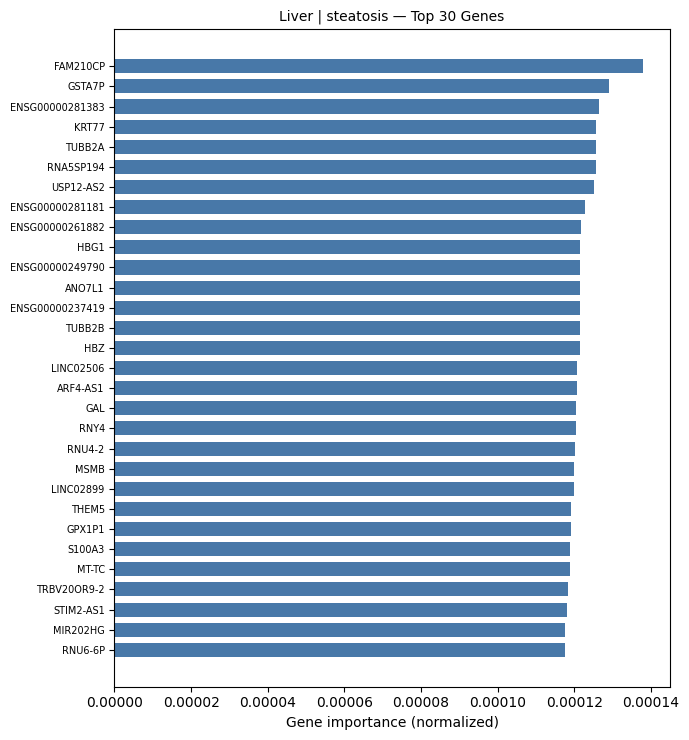

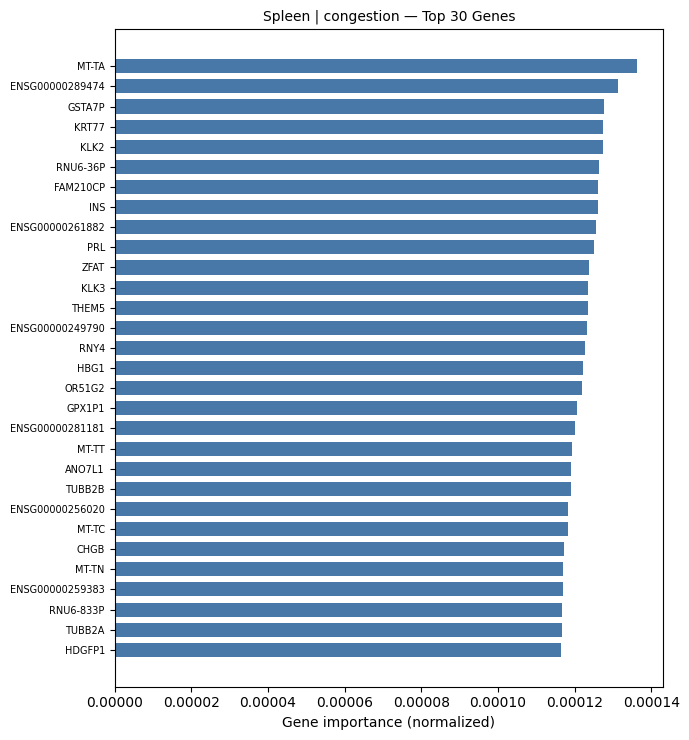

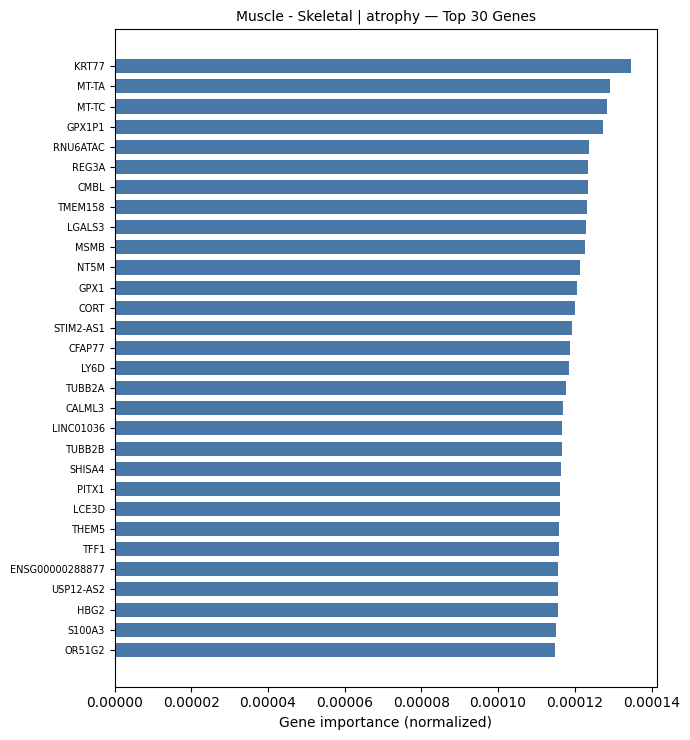

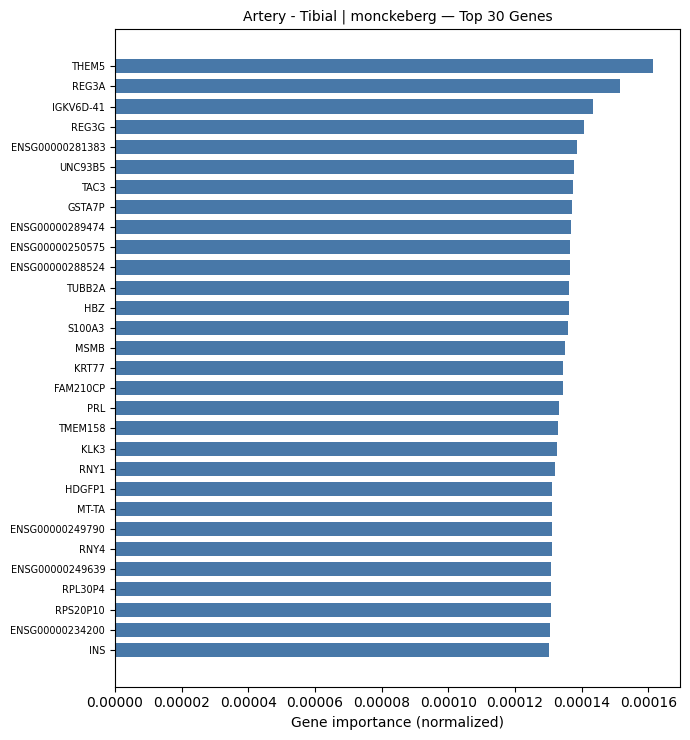

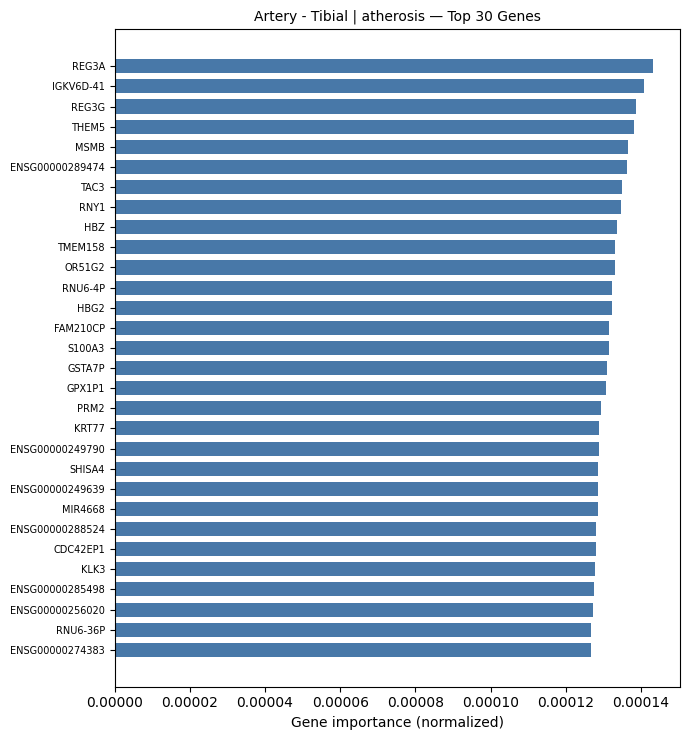

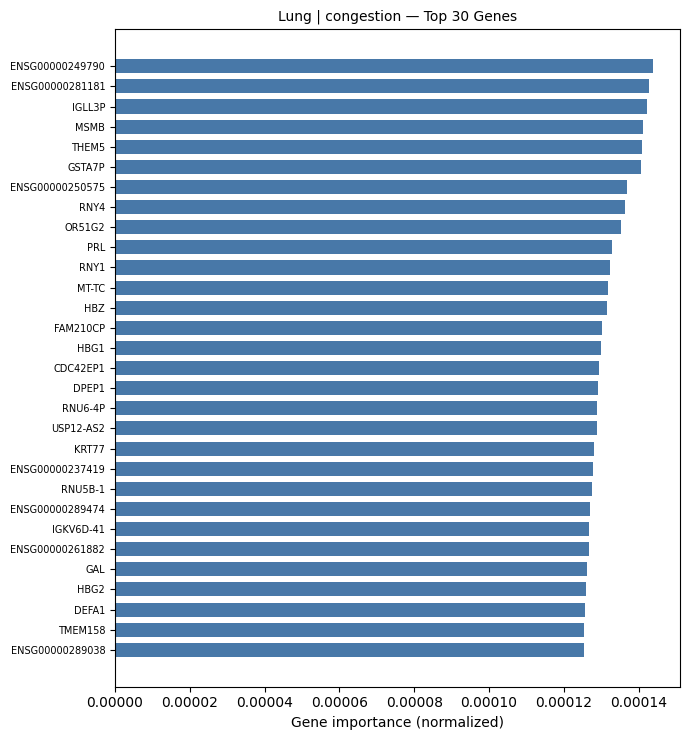

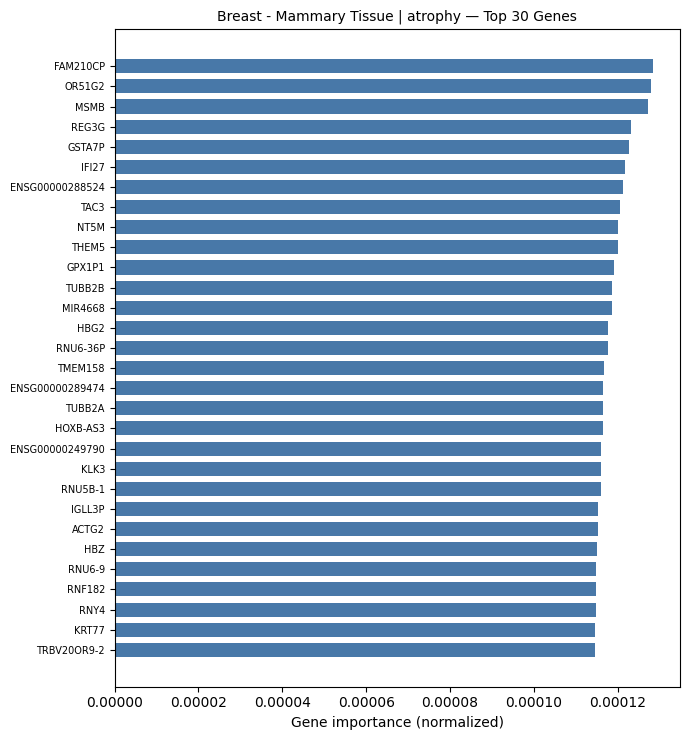

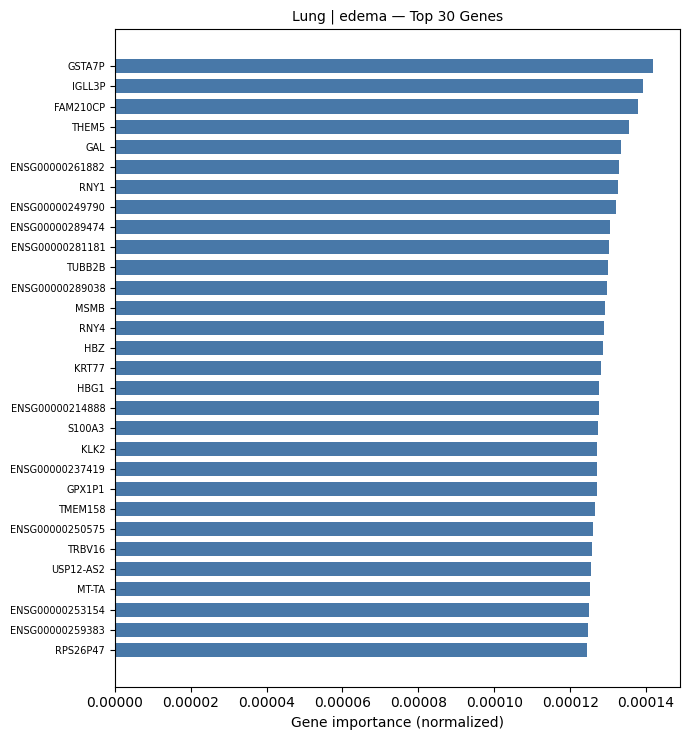

In [10]:
for (tissue, category), imp in gene_importance.items():
    if tissue == "Liver" and category == "cirrhosis":
        continue  # already plotted in 11.3

    top = imp.nlargest(TOP_N_GENES).sort_values()
    labels = [gene_id_to_name.get(g, g) for g in top.index]

    fig, ax = plt.subplots(figsize=(7, max(5, TOP_N_GENES * 0.25)))
    ax.barh(range(len(top)), top.values, color="#4878A8", height=0.7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("Gene importance (normalized)")
    ax.set_title(f"{tissue} | {category} \u2014 Top {TOP_N_GENES} Genes", fontsize=10)
    fig.tight_layout()
    plt.show()

## 11.7 — Validation: PC Importance vs Direct RF (NB07)

For each tissue × pathology pair, compare the gene ranking from our PC-based formula  
against the direct RF gene importance from NB07 (same pair).  
Spearman correlation measures how well the two rankings agree.

In [11]:
val_rows = []

for (tissue, category), imp in gene_importance.items():
    rf_pair = rf_fi[(rf_fi["tissue"] == tissue) & (rf_fi["category"] == category)]
    if rf_pair.empty:
        print(f"  {tissue} | {category}: no NB07 data — skipping")
        continue

    rf_direct = rf_pair.set_index("gene")["mean_importance"]
    common = imp.index.intersection(rf_direct.index)
    if len(common) < 10:
        continue

    rho, pval = spearmanr(imp[common], rf_direct[common])

    val_rows.append({
        "tissue": tissue, "category": category,
        "n_common_genes": len(common),
        "spearman_corr": rho, "p_value": pval,
    })
    print(f"  {tissue} | {category} — correlation: {rho:.3f}  (p={pval:.2e}, {len(common)} genes)")

val_df = pd.DataFrame(val_rows)
display(val_df)

  Liver | cirrhosis — correlation: 0.551  (p=8.18e-22, 257 genes)
  Liver | steatosis — correlation: 0.210  (p=4.26e-04, 278 genes)
  Spleen | congestion — correlation: 0.116  (p=9.34e-02, 211 genes)
  Muscle - Skeletal | atrophy — correlation: 0.290  (p=1.29e-07, 319 genes)
  Artery - Tibial | monckeberg — correlation: 0.411  (p=4.14e-13, 287 genes)
  Artery - Tibial | atherosis — correlation: 0.456  (p=2.50e-15, 271 genes)
  Lung | congestion — correlation: 0.267  (p=1.47e-05, 256 genes)
  Breast - Mammary Tissue | atrophy — correlation: 0.137  (p=2.05e-02, 286 genes)
  Lung | edema — correlation: 0.372  (p=9.86e-11, 284 genes)


,tissue,category,n_common_genes,spearman_corr,p_value
0,Liver,cirrhosis,257,0.551054,8.182664e-22
1,Liver,steatosis,278,0.209903,4.261305e-04
2,Spleen,congestion,211,0.115811,9.336485e-02
3,Muscle - Skeletal,atrophy,319,0.290406,1.286916e-07
4,Artery - Tibial,monckeberg,287,0.410764,4.138863e-13
5,Artery - Tibial,atherosis,271,0.456107,2.499050e-15
6,Lung,congestion,256,0.267213,1.467296e-05
7,Breast - Mammary Tissue,atrophy,286,0.136973,2.049185e-02
8,Lung,edema,284,0.371670,9.859924e-11


## 11.8 — Export

Save **all 20K genes** with importance scores for each qualifying pair.  
Downstream notebooks (NB12+) load this directly — no need to re-run the CV pipeline.

In [12]:
# Export ALL 20K genes per pair (full rankings for downstream use)
rows = []
for (tissue, category), imp in gene_importance.items():
    ranks = imp.rank(ascending=False).astype(int)
    for gene in imp.index:
        rows.append({
            "tissue": tissue, "category": category,
            "gene_id": gene,
            "gene_name": gene_id_to_name.get(gene, gene),
            "importance": imp[gene],
            "rank": ranks[gene],
        })

export_df = pd.DataFrame(rows).sort_values(["tissue", "category", "rank"]).reset_index(drop=True)
out_path = Config.TABLES_DIR / "pc_gene_importance_full.csv"
export_df.to_csv(out_path, index=False)
print(f"Saved {len(export_df)} rows ({len(gene_importance)} pairs × {X_wb_var.shape[1]:,} genes) to {out_path}")
display(export_df.head(10))

if not val_df.empty:
    val_df.to_csv(Config.TABLES_DIR / "validation_pc_vs_rf.csv", index=False)
    print(f"Saved validation to {Config.TABLES_DIR / 'validation_pc_vs_rf.csv'}")

Saved 180000 rows (9 pairs × 20,000 genes) to /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/tables/pc_gene_importance_full.csv


,tissue,category,gene_id,gene_name,importance,rank
0,Artery - Tibial,atherosis,ENSG00000172016.16,REG3A,0.000143,1
1,Artery - Tibial,atherosis,ENSG00000211626.2,IGKV6D-41,0.000141,2
2,Artery - Tibial,atherosis,ENSG00000143954.13,REG3G,0.000139,3
3,Artery - Tibial,atherosis,ENSG00000196407.12,THEM5,0.000138,4
4,Artery - Tibial,atherosis,ENSG00000263639.7,MSMB,0.000136,5
5,Artery - Tibial,atherosis,ENSG00000289474.1,ENSG00000289474,0.000136,6
6,Artery - Tibial,atherosis,ENSG00000166863.13,TAC3,0.000135,7
7,Artery - Tibial,atherosis,ENSG00000201098.1,RNY1,0.000135,8
8,Artery - Tibial,atherosis,ENSG00000130656.6,HBZ,0.000134,9
9,Artery - Tibial,atherosis,ENSG00000249992.2,TMEM158,0.000133,10


Saved validation to /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/output/tables/validation_pc_vs_rf.csv
